<a href="https://colab.research.google.com/github/zaidan-khairiazhar/machine-learning-python/blob/main/ML_Method_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-1606336154.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


### Classification Report ###
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.54      0.72      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409


### Confusion Matrix ###


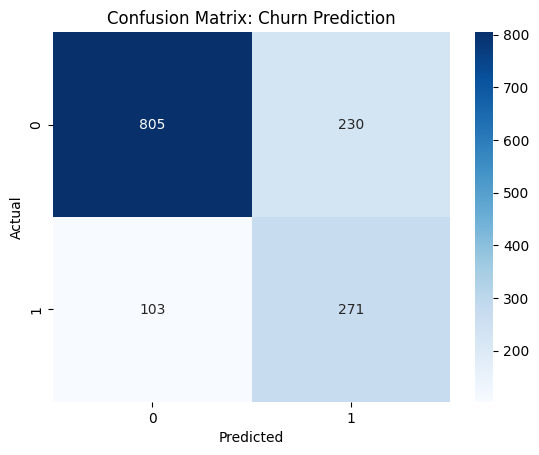

/tmp/ipython-input-1606336154.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


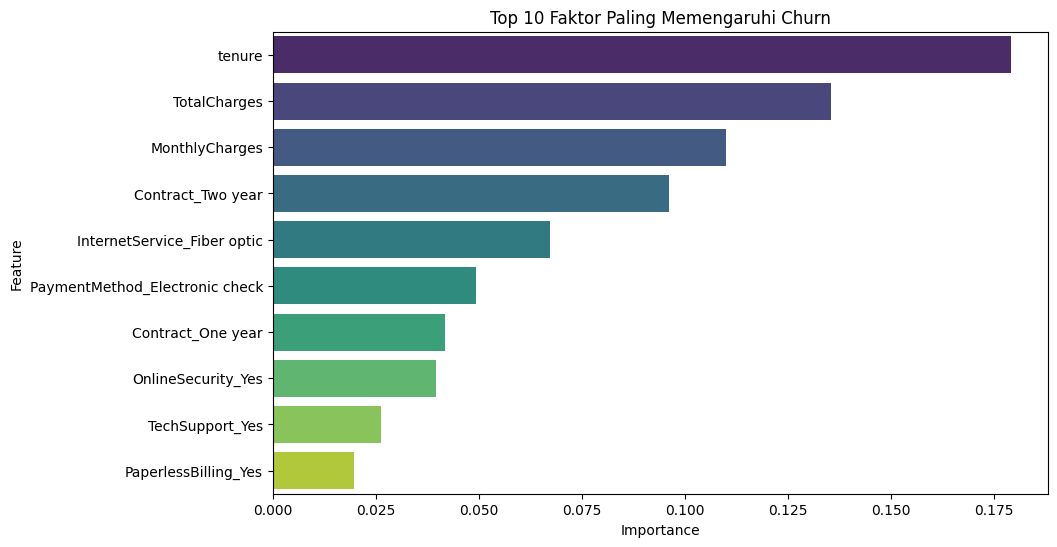

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# 1. Load Data
# Pastikan file CSV sudah di-download dari Kaggle
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# --- DATA CLEANING & PREPROCESSING ---

# 'TotalCharges' terbaca sebagai object karena ada spasi kosong " ", kita ubah ke numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Mengisi nilai NaN yang muncul (hanya sedikit baris) dengan 0 atau median
df['TotalCharges'].fillna(0, inplace=True)

# Hapus kolom 'customerID' karena tidak berguna untuk prediksi
df.drop('customerID', axis=1, inplace=True)

# Mengubah target 'Churn' (Yes/No) menjadi angka (1/0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Encoding variabel kategorikal (One-Hot Encoding)
# get_dummies akan mengubah kolom teks seperti 'PaymentMethod', 'Contract' menjadi angka
df_encoded = pd.get_dummies(df, drop_first=True)

# --- SPLITTING DATA ---

X = df_encoded.drop('Churn', axis=1) # Fitur
y = df_encoded['Churn']              # Target

# Bagi data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- MODELING: RANDOM FOREST ---

# Kita gunakan class_weight='balanced' karena biasanya data churn tidak seimbang (imbalanced)
rf_model = RandomForestClassifier(n_estimators=100,
                                  random_state=42,
                                  max_depth=10,
                                  class_weight='balanced')

rf_model.fit(X_train, y_train)

# --- PREDIKSI & EVALUASI ---

y_pred = rf_model.predict(X_test)

print("### Classification Report ###")
print(classification_report(y_test, y_pred))

print("\n### Confusion Matrix ###")
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Churn Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- FEATURE IMPORTANCE ---

importances = rf_model.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Top 10 Faktor Paling Memengaruhi Churn')
plt.show()